In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import lime
import lime.lime_tabular

/tmp/ipykernel_2320310/1979477410.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv("ResearhData.csv")
print(df.shape)
df.head()

(2541, 13)


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
0,NOSTRESS,-0.030326,-0.030742,0.000124,0.0,0.0,-0.810,0.3750,-1.121333,-0.036966,-0.5,-33.871843,-0.488629
1,NOSTRESS,-0.027412,-0.028501,0.003034,0.0,0.0,-1.320,0.3675,-0.771936,0.317007,-0.5,-33.871843,-0.488629
2,NOSTRESS,-0.027540,-0.028821,0.002604,0.0,0.0,-1.380,0.3625,-0.913694,0.263580,-0.5,-33.871843,-0.488629
3,NOSTRESS,-0.018734,-0.016492,0.004473,0.0,0.0,-2.285,0.4050,-0.272774,0.462842,-0.5,-33.871843,-0.488629
4,NOSTRESS,-0.012041,-0.014570,-0.005277,0.0,0.0,-2.715,0.4125,0.057561,0.002796,-0.5,-33.871843,-0.488629


In [3]:
df['Label'].unique()

array(['NOSTRESS', 'STRESS'], dtype=object)

## Data Description 

In [4]:
df.describe(include='all')

,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
count,2541,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.133460,0.134660,0.011387,0.226682,0.025125,9.303126,-0.317973,-0.110210,0.621465,-1.519776,-31.099023,-0.441252
std,NaN,0.310719,0.314339,0.039412,0.783278,0.105890,14.661003,0.599100,0.877497,1.110321,13.332870,32.091973,4.118833
min,NaN,-1.083348,-1.065445,-0.064407,-4.000000,-0.219829,-29.775000,-2.073750,-11.392412,-7.634984,-43.500000,-99.875000,-18.977173
25%,NaN,0.038008,0.039704,-0.000006,0.000000,0.000000,0.325000,-0.748750,-0.581779,0.045387,-10.000000,-52.300000,-2.154263
50%,NaN,0.085989,0.086309,0.001395,0.000000,0.000000,7.800000,-0.265000,-0.127017,0.250669,-0.500000,-33.871843,-0.488629
75%,NaN,0.157703,0.159619,0.007714,0.000000,0.000000,15.570000,0.067500,0.366051,0.993110,8.000000,-11.863636,1.978926


## Missingness

In [5]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts[missing_counts > 2541/2]

missing_counts.sort_values(ascending=False)

Series([], dtype: int64)

## Low Variability

In [6]:
from sklearn.feature_selection import VarianceThreshold

df_num = df.select_dtypes(include=['number'])

# Set your variance threshold (e.g., 0.01 is a common starting point)
my_threshold = 0.01
selector = VarianceThreshold(threshold=my_threshold)
selector.fit(df_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = df_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(my_threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['EDA_sd_delta']


In [7]:
for col in df.select_dtypes(include='object'):
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [8]:
df.dtypes

Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object

## Sampling 

In [9]:
pd.crosstab(index = df['Label'], columns = "count") 

col_0,count
Label,
NOSTRESS,1229
STRESS,1312


In [10]:
train = df.groupby("Label", group_keys=False).sample(frac=0.75, random_state=1234)
test = df.loc[df.index.difference(train.index)]
train.head()


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
2220,NOSTRESS,-0.091091,-0.091315,0.000187,-2.0,-0.043149,35.41,-0.2400,-0.450977,0.439211,-1.0,-62.000000,-4.964245
850,NOSTRESS,-0.031503,-0.033947,0.009839,0.5,0.041946,57.27,-1.3125,-0.497868,2.271804,10.0,-54.428571,-1.730073
427,NOSTRESS,0.194776,0.194680,-0.000229,0.0,0.000000,-28.80,1.3750,1.841169,0.090760,2.0,-44.550000,-0.622952
1162,NOSTRESS,0.340880,0.340912,0.000109,0.5,0.041793,11.06,-0.5550,-0.509152,0.090518,-19.0,-32.500000,-1.842775
849,NOSTRESS,-0.043683,-0.041794,0.002562,0.0,0.000000,56.23,-1.3225,0.495889,0.220549,8.5,-57.918182,-4.616893


In [11]:
pd.crosstab(index = train['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,922
STRESS,984


In [12]:
pd.crosstab(index = test['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,307
STRESS,328


In [13]:
# filling in number dtypes with median and flagging with missing 
train_o = train.copy()
num_cols = train_o.select_dtypes(include='number').columns

for col in num_cols:
    if train_o[col].isnull().any():
        # Create missing flag column
        train_o[f'{col}_was_missing'] = train_o[col].isnull().astype(int)

        # Impute with median
        median = train_o[col].median()
        train_o[col] = train_o[col].fillna(median)
print(train_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [14]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(train_o.dtypes)


Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object


In [15]:
# creating X and Y and creating dummies for categorical data 
predictors = train_o.drop(columns=['Label'])
predictors = pd.get_dummies(predictors, drop_first=True)
predictors = predictors.astype(float)

X = predictors

y = train_o['Label']



In [16]:
# using Pearson's square to sort data and determine association, 
# Use p-value of 0.002 depending on the data siize
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Separate categorical (dummy) vs. continuous features
continuous_features = [col for col in X.columns if X[col].nunique() > 2]

X_cont = X[continuous_features]




# Fit SelectKBest for Continous Variables
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' keeps all features for scoring
selector.fit(X_cont, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_cont_df = pd.DataFrame({
    'Feature': X_cont.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Filter for features with p-value < 0.002
selected_cont_features = scores_cont_df[scores_cont_df['p_value'] < 0.002]['Feature']

# Create a new DataFrame with only those selected columns
X_reduced = X[selected_cont_features.tolist()]

X_reduced.head()


,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
2220,-0.091091,-0.091315,0.000187,-2.0,-0.043149,-0.2400,0.439211,-1.0
850,-0.031503,-0.033947,0.009839,0.5,0.041946,-1.3125,2.271804,10.0
427,0.194776,0.194680,-0.000229,0.0,0.000000,1.3750,0.090760,2.0
1162,0.340880,0.340912,0.000109,0.5,0.041793,-0.5550,0.090518,-19.0
849,-0.043683,-0.041794,0.002562,0.0,0.000000,-1.3225,0.220549,8.5


## Lasso Regression 

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
import pandas as pd
import numpy as np

# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)  # X_reduced must match feature_names

# --- Logistic LASSO with Cross-Validation ---
lasso_clf = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l1',
    solver='saga',
    scoring='roc_auc',
    max_iter=10000,
    n_jobs=-1,
    refit=True,
    random_state=1234
)

lasso_clf.fit(X_scaled, y)
feature_names = X_reduced.columns

# --- Coefficient table ---
lasso_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_clf.coef_.flatten()
})

# Sort by absolute coefficient magnitude
lasso_df['Abs_Coefficient'] = np.abs(lasso_df['Coefficient'])
lasso_df = lasso_df.sort_values(by='Abs_Coefficient', ascending=False)

lasso_df['Model'] = "Logistic Lasso CV"

print("Logistic Lasso CV - Top 10 coefficients")
print(lasso_df.head(10))


Logistic Lasso CV - Top 10 coefficients
             Feature  Coefficient  Abs_Coefficient              Model
1   EDA_median_delta    -6.047765         6.047765  Logistic Lasso CV
0     EDA_mean_delta     5.824732         5.824732  Logistic Lasso CV
5  TEMP_median_delta    -0.497502         0.497502  Logistic Lasso CV
7    HR_bangle_delta     0.263417         0.263417  Logistic Lasso CV
2       EDA_sd_delta    -0.232149         0.232149  Logistic Lasso CV
6    ACC_vm_sd_delta    -0.149028         0.149028  Logistic Lasso CV
3    SCR_count_delta    -0.143109         0.143109  Logistic Lasso CV
4      SCR_amp_delta     0.013507         0.013507  Logistic Lasso CV


 ## Ridge Logistic

<Figure size 1800x1000 with 0 Axes>

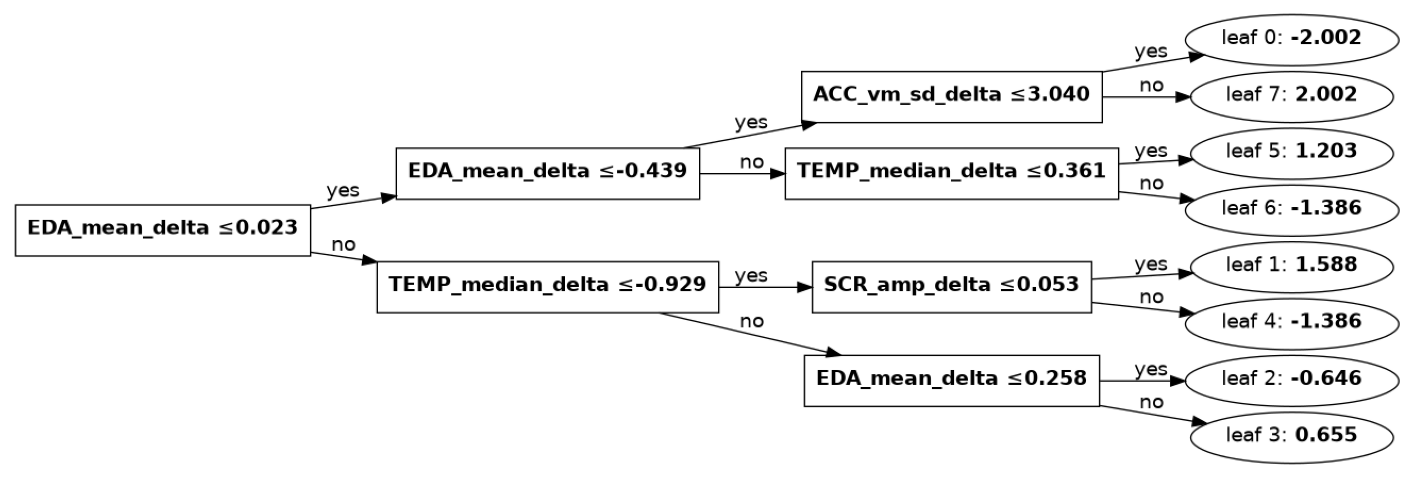

In [19]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Convert labels to binary
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})

# Create LightGBM dataset
lgb_train = lgb.Dataset(X_reduced, label=y)

# LightGBM parameters (equivalent to max_depth=3, single tree)
params = {
    'objective': 'binary',
    'random_state': 1234,
    'max_depth': 3,        # tree depth
    'num_leaves': 8,        # should be <= 2^max_depth
    'learning_rate': 1.0,   # high learning rate since only 1 tree
    'n_estimators': 1,
    'min_data_in_leaf': 1,
    'verbose': -1
}

# Train LightGBM model
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1  # single tree
)

# Plot the tree
plt.figure(figsize=(18, 10))
lgb.plot_tree(lgb_model, tree_index=0, figsize=(18, 10))
plt.show()


In [18]:
Cs = np.logspace(-2, 2, 6)  # fewer, smoother values
ridge_clf = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty='l2',
    solver='lbfgs',  # lbfgs works well for L2
    scoring='roc_auc',
    max_iter=10000,
    n_jobs=-1,
    refit=True,
    random_state=1234
)
ridge_clf.fit(X_scaled, y)
feature_names = X_reduced.columns

ridge_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_clf.coef_.flatten()
}).sort_values(by='Coefficient', key=abs, ascending=False)
ridge_df['Model'] = "Logistic Ridge CV"

print("Logistic Ridge CV - Top 10 coefficients")
print(ridge_df.head(10))



The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Logistic Ridge CV - Top 10 coefficients
             Feature  Coefficient              Model
1   EDA_median_delta    -7.163775  Logistic Ridge CV
0     EDA_mean_delta     6.925009  Logistic Ridge CV
5  TEMP_median_delta    -0.500857  Logistic Ridge CV
2       EDA_sd_delta    -0.273390  Logistic Ridge CV
7    HR_bangle_delta     0.263875  Logistic Ridge CV
6    ACC_vm_sd_delta    -0.148931  Logistic Ridge CV
3    SCR_count_delta    -0.138749  Logistic Ridge CV
4      SCR_amp_delta     0.054924  Logistic Ridge CV


## Elastic Logistic combining L1 and L2 

In [20]:

elastic_clf = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty='elasticnet',
    solver='saga',      # saga supports elasticnet
    l1_ratios=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],    # mix of L1 and L2
    scoring='roc_auc',
    max_iter=10000,
    n_jobs=-1,
    refit=True,
    random_state=42
)
elastic_clf.fit(X_scaled, y)

elastic_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': elastic_clf.coef_.flatten()
}).sort_values(by='Coefficient', key=abs, ascending=False)
elastic_df['Model'] = "Logistic Elastic Net CV"

print("Logistic Elastic Net CV - Top 10 coefficients")
print(elastic_df.head(10))

Logistic Elastic Net CV - Top 10 coefficients
             Feature  Coefficient                    Model
1   EDA_median_delta    -6.249538  Logistic Elastic Net CV
0     EDA_mean_delta     6.023751  Logistic Elastic Net CV
5  TEMP_median_delta    -0.498197  Logistic Elastic Net CV
7    HR_bangle_delta     0.263542  Logistic Elastic Net CV
2       EDA_sd_delta    -0.241043  Logistic Elastic Net CV
6    ACC_vm_sd_delta    -0.149020  Logistic Elastic Net CV
3    SCR_count_delta    -0.142432  Logistic Elastic Net CV
4      SCR_amp_delta     0.022558  Logistic Elastic Net CV


In [21]:
from sklearn.metrics import roc_auc_score
import pandas as pd

def compute_auc_somersd(model, X, y, model_name):
    """
    Compute AUC (C-statistic) and Somer's D for a given model.
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Compute AUC
    auc = roc_auc_score(y, y_prob)
    
    # Compute Somer’s D
    somers_d = 2 * auc - 1
    
    print(f"\n{model_name} Model Performance:")
    print(f"AUC (C-statistic): {auc:.4f}")
    print(f"Somer's D: {somers_d:.4f}")
    
    return {
        "Model": model_name,
        "AUC": auc,
        "Somer's D": somers_d
    }

# --- Compute for all models (pass the fitted model objects) ---
results = []
results.append(compute_auc_somersd(ridge_clf, X_scaled, y, "Ridge"))
results.append(compute_auc_somersd(lasso_clf, X_scaled, y, "Lasso"))
results.append(compute_auc_somersd(elastic_clf, X_scaled, y, "Elastic Net"))

# --- Display summary table ---
auc_summary = pd.DataFrame(results)
print("\nSummary of AUC and Somer's D:")
print(auc_summary)



Ridge Model Performance:
AUC (C-statistic): 0.7047
Somer's D: 0.4093

Lasso Model Performance:
AUC (C-statistic): 0.7042
Somer's D: 0.4084

Elastic Net Model Performance:
AUC (C-statistic): 0.7043
Somer's D: 0.4085

Summary of AUC and Somer's D:
         Model       AUC  Somer's D
0        Ridge  0.704651   0.409302
1        Lasso  0.704194   0.408389
2  Elastic Net  0.704253   0.408506


In [25]:
import pandas as pd
from sklearn.metrics import roc_curve

def best_threshold(model, X, y, model_name):
    """
    Compute the best cutoff using Youden's Index for a model.
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Ensure y is integer
    label_map = {'NOSTRESS': 0, 'STRESS': 1}


    y_true = train_o['Label'].map(label_map)
    
    # Check for constant values
    if len(set(y_true)) < 2:
        raise ValueError(f"{model_name}: y_true has only one class. Need both positive and negative samples.")
    
    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    # Build Youden's index table
    youden = pd.DataFrame({
        'TPR': tpr,
        'FPR': fpr,
        'Cut-off': thresholds,
        'Youden': tpr - fpr
    }).sort_values(by='Youden', ascending=False).reset_index(drop=True)
    
    # Best cutoff
    best_cutoff = youden.loc[0, 'Cut-off']
    print(f"\n{model_name} Best Threshold (Youden's Index): {best_cutoff:.4f}")
    
    return youden, best_cutoff

# --- Compute best thresholds for all models ---
youden_ridge, cutoff_ridge = best_threshold(ridge_clf, X_scaled, y, "Ridge")
youden_lasso, cutoff_lasso = best_threshold(lasso_clf, X_scaled, y, "Lasso")
youden_elastic, cutoff_elastic = best_threshold(elastic_clf, X_scaled, y, "Elastic Net")

# Optional: show top 5 thresholds for Ridge
youden_ridge.head()



Ridge Best Threshold (Youden's Index): 0.5490

Lasso Best Threshold (Youden's Index): 0.5474

Elastic Net Best Threshold (Youden's Index): 0.5482


,TPR,FPR,Cut-off,Youden
0,0.592480,0.262473,0.549032,0.330007
1,0.593496,0.263557,0.548012,0.329938
2,0.594512,0.264642,0.547701,0.329870
3,0.592480,0.263557,0.548700,0.328922
4,0.593496,0.264642,0.547790,0.328854


In [28]:
import pandas as pd

def compute_confusion_matrix(model, X, y, model_name, cutoff):
    """
    Compute confusion matrix using a probability cutoff.
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Convert probabilities to binary predictions using cutoff
    y_pred = (y_prob > cutoff).astype(int)
    
    # Confusion matrix as crosstab
    cm = pd.crosstab(y, y_pred, rownames=['Actual'], colnames=['Predicted'])
    
    print(f"\n{model_name} Confusion Matrix (cutoff={cutoff}):")
    print(cm)
    
    return cm

# --- Compute confusion matrices for all models ---
cm_ridge = compute_confusion_matrix(ridge_clf, X_scaled, y, "Ridge",0.5490)
cm_lasso = compute_confusion_matrix(lasso_clf, X_scaled, y, "Lasso",0.5474)
cm_elastic = compute_confusion_matrix(elastic_clf, X_scaled, y, "Elastic Net",0.5482)



Ridge Confusion Matrix (cutoff=0.549):
Predicted    0    1
Actual             
0          680  242
1          401  583

Lasso Confusion Matrix (cutoff=0.5474):
Predicted    0    1
Actual             
0          678  244
1          400  584

Elastic Net Confusion Matrix (cutoff=0.5482):
Predicted    0    1
Actual             
0          679  243
1          403  581


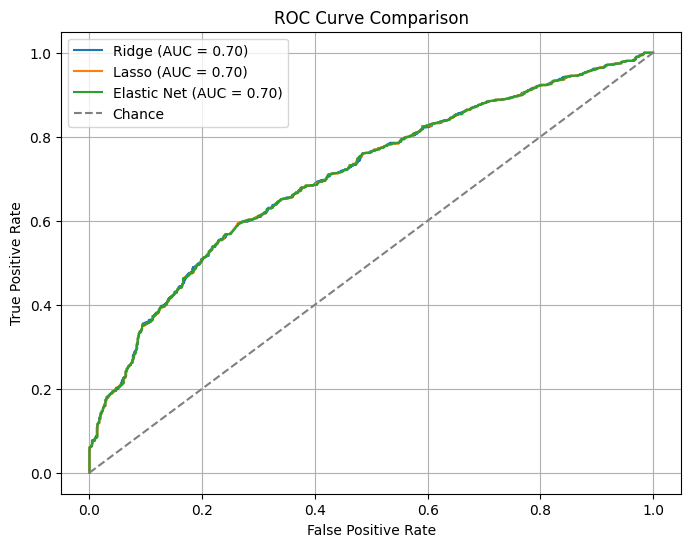

Ridge AUC: 0.7047
Lasso AUC: 0.7042
Elastic Net AUC: 0.7043


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc(model, X, y, model_name):
    """Plot ROC curve with AUC for a given model."""
    y_prob = model.predict_proba(X)[:, 1]
    y_true = y.astype(int)
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.2f})")
    return fpr, tpr, auc_val

# --- Plot all models together ---
plt.figure(figsize=(8,6))

fpr_ridge, tpr_ridge, auc_ridge = plot_roc(ridge_clf, X_scaled, y, "Ridge")
fpr_lasso, tpr_lasso, auc_lasso = plot_roc(lasso_clf, X_scaled, y, "Lasso")
fpr_elastic, tpr_elastic, auc_elastic = plot_roc(elastic_clf, X_scaled, y, "Elastic Net")

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# --- Print AUC values ---
print(f"Ridge AUC: {auc_ridge:.4f}")
print(f"Lasso AUC: {auc_lasso:.4f}")
print(f"Elastic Net AUC: {auc_elastic:.4f}")


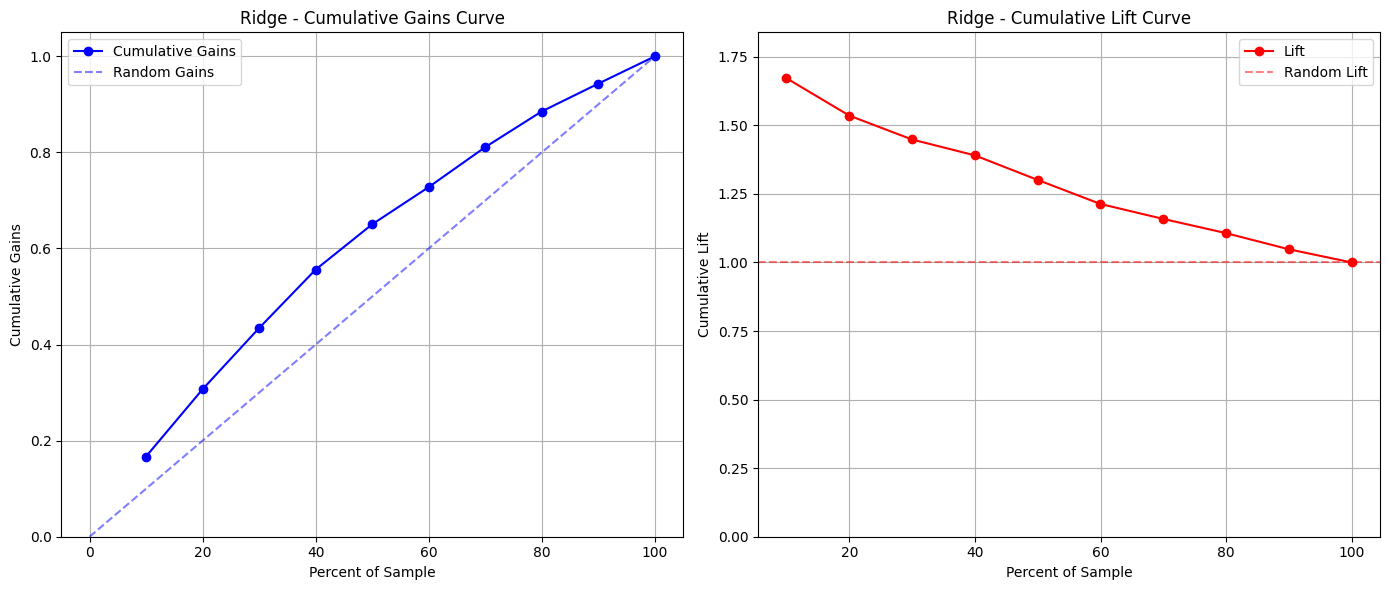

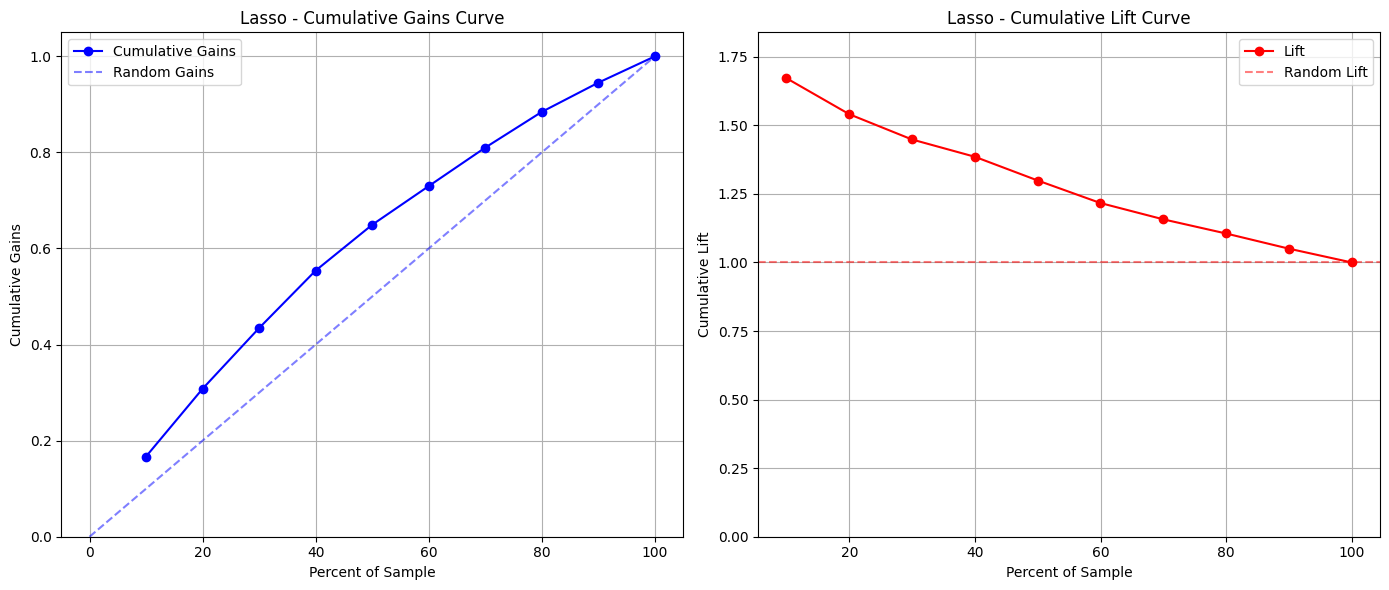

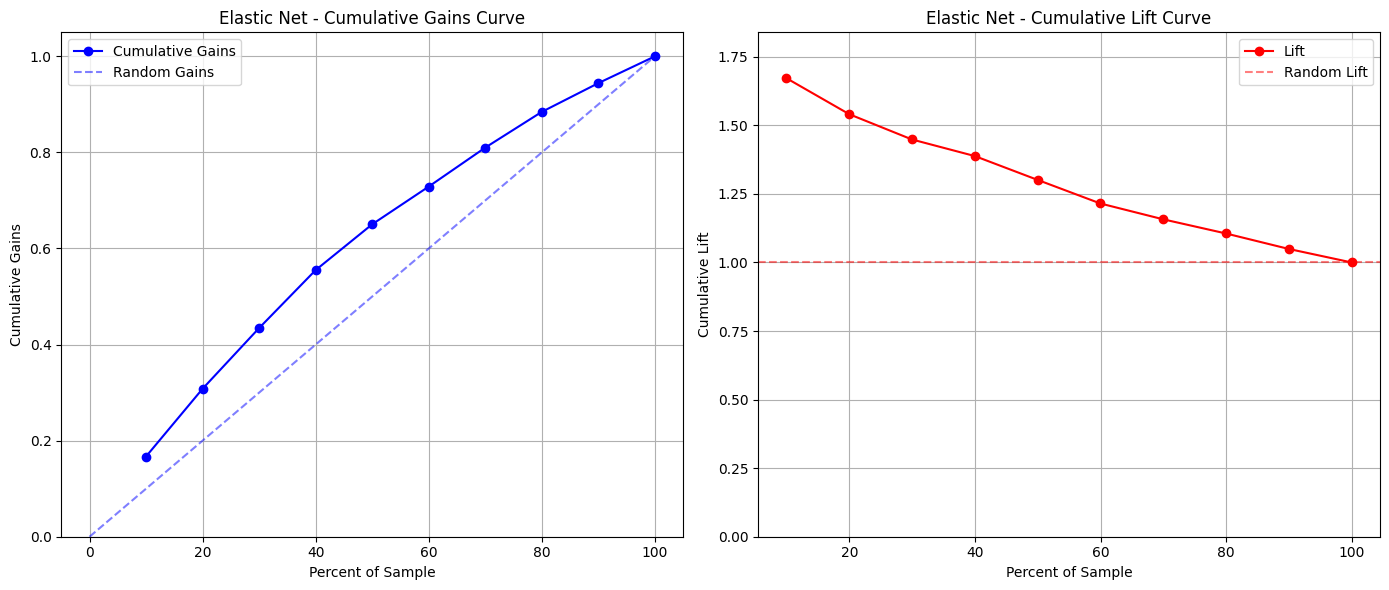

In [30]:
# --- Gains and Lift Plots for Ridge, Lasso, and Elastic Net ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_and_gains_model(model, X, y, model_name, n_bins=10):
    """
    Plot Lift and Cumulative Gains curves for a given model.
    
    Parameters:
    - model: trained model with predict_proba method
    - X: features
    - y: true binary labels
    - model_name: string, model label for title
    - n_bins: number of bins/deciles
    """
    y_true = y.astype(int)
    y_proba = model.predict_proba(X)[:, 1]
    
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    
    # Sort descending by predicted probability
    df = df.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    
    # Cumulative counts
    df['cum_total'] = np.arange(1, len(df)+1)
    df['cum_positives'] = df['y_true'].cumsum()
    
    total_positives = df['y_true'].sum()
    total_samples = len(df)
    
    # Cumulative Gains and Lift
    df['cum_gains'] = df['cum_positives'] / total_positives
    df['cum_lift'] = df['cum_gains'] / (df['cum_total'] / total_samples)
    
    # Sample points for plotting
    cutoffs = np.linspace(0, total_samples, n_bins+1, dtype=int)
    cutoffs = cutoffs[cutoffs > 0]
    plot_points = df.loc[cutoffs-1, ['cum_total', 'cum_gains', 'cum_lift']].copy()
    plot_points['percent_samples'] = plot_points['cum_total'] / total_samples * 100
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    
    # Cumulative Gains
    axes[0].plot(plot_points['percent_samples'], plot_points['cum_gains'], marker='o', color='blue', label='Cumulative Gains')
    axes[0].plot([0,100], [0,1], linestyle='--', color='blue', alpha=0.5, label='Random Gains')
    axes[0].set_xlabel('Percent of Sample')
    axes[0].set_ylabel('Cumulative Gains')
    axes[0].set_title(f'{model_name} - Cumulative Gains Curve')
    axes[0].set_ylim(0,1.05)
    axes[0].grid(True)
    axes[0].legend()
    
    # Cumulative Lift
    axes[1].plot(plot_points['percent_samples'], plot_points['cum_lift'], marker='o', color='red', label='Lift')
    axes[1].axhline(1, linestyle='--', color='red', alpha=0.5, label='Random Lift')
    axes[1].set_xlabel('Percent of Sample')
    axes[1].set_ylabel('Cumulative Lift')
    axes[1].set_title(f'{model_name} - Cumulative Lift Curve')
    axes[1].set_ylim(0, plot_points['cum_lift'].max()*1.1)
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# --- Generate Gains and Lift plots for all models ---
plot_lift_and_gains_model(ridge_clf, X_scaled, y, "Ridge")
plot_lift_and_gains_model(lasso_clf, X_scaled, y, "Lasso")
plot_lift_and_gains_model(elastic_clf, X_scaled, y, "Elastic Net")


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

def plot_ks(model, X, y, model_name):
    """
    Plot KS (Kolmogorov-Smirnov) statistic curve for a given model.
    
    Parameters:
    - model: fitted model with predict_proba method
    - X: feature matrix
    - y: true binary labels
    - model_name: string for title/legend
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    y_true = y.astype(int)
    
    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    # Build Youden DataFrame
    youden = pd.DataFrame({
        'Cut-off': thresholds,
        'TPR': tpr,
        'FPR': fpr,
        'Youden': tpr - fpr
    }).sort_values(by='Cut-off', ascending=True)
    
    # Prepare data for seaborn lineplot
    ks_stat = youden.rename(columns={'TPR': 'PR_T', 'FPR': 'PR_F'})
    ks_stat = ks_stat.melt(id_vars='Cut-off', var_name='PR', value_name='value')
    
    # KS value and cutoff
    ks_val = youden['TPR'].sub(youden['FPR']).max()
    ks_cutoff = youden.loc[(youden['TPR'] - youden['FPR']).idxmax(), 'Cut-off']
    
    # Plot
    plt.figure(figsize=(8,6))
    sns.lineplot(x='Cut-off', y='value', hue='PR', data=ks_stat)
    plt.xlim(1, 0)
    plt.title(f"KS Plot - {model_name} (KS = {ks_val:.2f})")
    plt.grid(True)
    plt.axvline(x=ks_cutoff, linestyle='--', color='red', label=f'KS cutoff = {ks_cutoff:.4f}')
    plt.legend()
    plt.show()
    
    return ks_val, ks_cutoff


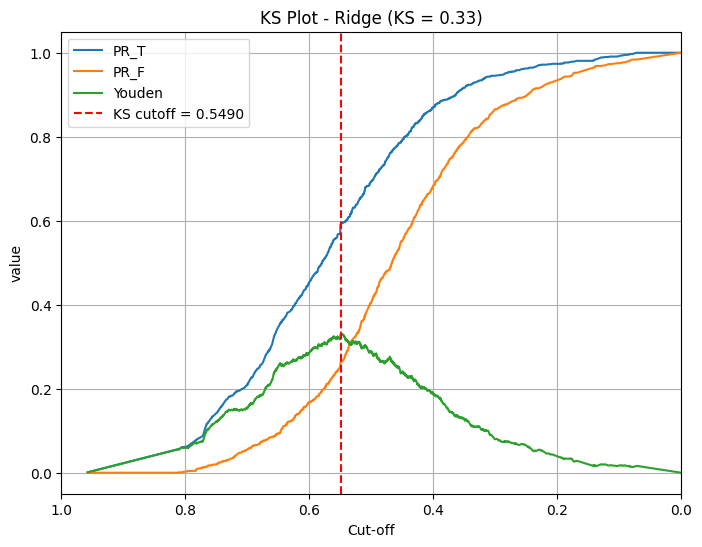

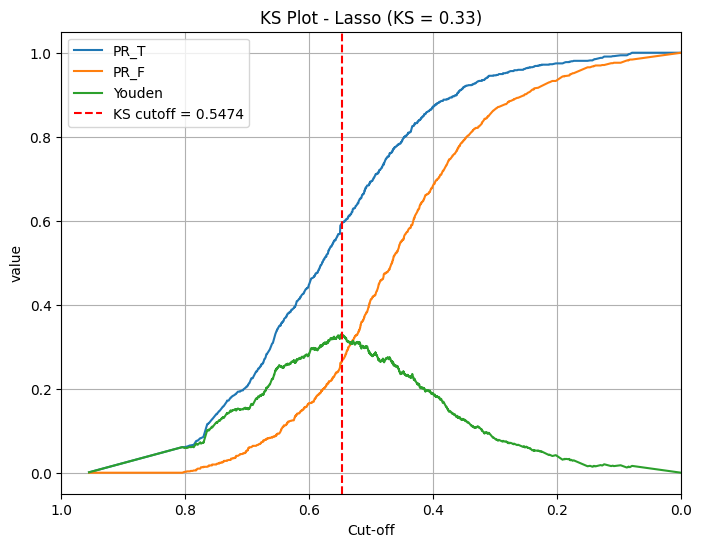

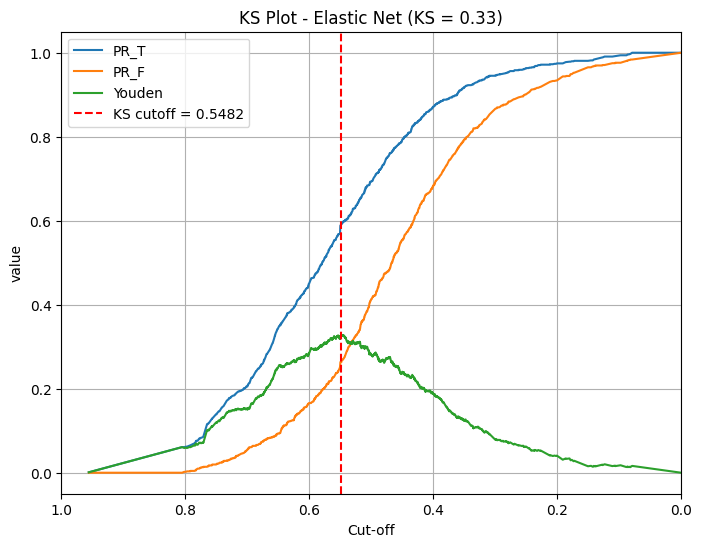

In [32]:
ks_ridge, ks_cutoff_ridge = plot_ks(ridge_clf, X_scaled, y, "Ridge")
ks_lasso, ks_cutoff_lasso = plot_ks(lasso_clf, X_scaled, y, "Lasso")
ks_elastic, ks_cutoff_elastic = plot_ks(elastic_clf, X_scaled, y, "Elastic Net")


## Testing 

## Test data Transformation

In [33]:
test_o= test.copy()
num_cols_test = test_o.select_dtypes(include='number').columns

for col in num_cols_test:
    if test_o[col].isnull().any():
        # Create missing flag column
        test_o[f'{col}_was_missing'] = test_o[col].isnull().astype(int)

        # Impute with median
        median = test_o[col].median()
        test_o[col] = test_o[col].fillna(median)
print(test_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [43]:
# --- Step 1: Prepare test predictors ---
predictors_test = test_o.drop(columns=['Label'])
predictors_test = pd.get_dummies(predictors_test, drop_first=True)
predictors_test = predictors_test.astype(float)

# --- Step 2: Align test features with training features ---
# Use the columns from X_train (before scaling)
train_columns = X_reduced.columns  # or X_selected.columns if you selected features

# Add missing columns in test set
for col in train_columns:
    if col not in predictors_test.columns:
        predictors_test[col] = 0

# Remove extra columns not in training
predictors_test = predictors_test[train_columns]

# Now X_test matches X_train exactly
X_test = predictors_test
y_test = test_o['Label']

# --- Step 3: Scale using the training scaler ---
X_test_scaled = scaler.transform(X_test)
y_test = test_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})

# Check
X_test_scaled.shape, X_test.head()


((635, 8),
     EDA_mean_delta  EDA_median_delta  EDA_sd_delta  SCR_count_delta  \
 3        -0.018734         -0.016492      0.004473              0.0   
 5        -0.015467         -0.016652      0.001588              0.0   
 10       -0.014058         -0.013610      0.000711              0.0   
 12       -0.013642         -0.014090     -0.000039              0.0   
 15       -0.013418         -0.012809     -0.001220              0.0   
 
     SCR_amp_delta  TEMP_median_delta  ACC_vm_sd_delta  HR_bangle_delta  
 3             0.0             0.4050         0.462842             -0.5  
 5             0.0             0.4200        -0.028379             -0.5  
 10            0.0             0.4450         0.067591             -0.5  
 12            0.0             0.4075         0.033248             -0.5  
 15            0.0             0.4400        -0.393227             -0.5  )

In [44]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, confusion_matrix, classification_report
)
import pandas as pd

def evaluate_classification(model, X, y, model_name, threshold=0.5):
    """
    Compute classification metrics for a given model and threshold.
    
    Parameters:
    - model: fitted model with predict_proba
    - X: features
    - y: true binary labels
    - model_name: string label for output
    - threshold: probability cutoff for binary prediction
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Convert probabilities to binary predictions using threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Compute metrics
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # Confusion matrix and classification report
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=4)
    
    # Display results
    print(f"\n====== {model_name} CLASSIFICATION PERFORMANCE ======")
    print(f"Threshold: {threshold:.6f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(report)
    
    # Return metrics as dictionary for further analysis
    metrics_dict = {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'ROC-AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ConfusionMatrix': cm,
        'ClassificationReport': report
    }
    
    return metrics_dict


In [46]:
# Example: using thresholds from cost-sensitive or Youden's index
metrics_ridge = evaluate_classification(ridge_clf, X_test_scaled, y_test, "Ridge", threshold=0.5490)
metrics_lasso = evaluate_classification(lasso_clf, X_test_scaled, y_test, "Lasso", threshold=0.5474)
metrics_elastic = evaluate_classification(elastic_clf, X_test_scaled, y_test, "Elastic Net", threshold=0.5482)



====== Ridge CLASSIFICATION PERFORMANCE ======
Threshold: 0.549000
Accuracy : 0.6126
ROC-AUC  : 0.6558
Precision: 0.6454
Recall   : 0.5549
F1 Score : 0.5967

Confusion Matrix:
[[207 100]
 [146 182]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5864    0.6743    0.6273       307
           1     0.6454    0.5549    0.5967       328

    accuracy                         0.6126       635
   macro avg     0.6159    0.6146    0.6120       635
weighted avg     0.6169    0.6126    0.6115       635


====== Lasso CLASSIFICATION PERFORMANCE ======
Threshold: 0.547400
Accuracy : 0.6142
ROC-AUC  : 0.6563
Precision: 0.6477
Recall   : 0.5549
F1 Score : 0.5977

Confusion Matrix:
[[208  99]
 [146 182]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5876    0.6775    0.6293       307
           1     0.6477    0.5549    0.5977       328

    accuracy                         0.6142       635
   macr